# Airbnb Price Prediction: Model Selection to Final Two-Part Results

This notebook consolidates the full workflow into one place: baseline model comparison, model selection, error analysis, segmentation strategy, and the final two-part prediction setup.

Main goals:
- compare baseline models on the cleaned Airbnb NYC dataset
- identify why a single global model struggles
- evaluate segmented modeling by `room_type`
- split the task into typical listings (`price < 500`) and high-price listings (`price >= 500`)
- report the final recommended model and its performance


## 1. Imports & Configuration
Set up libraries used throughout the notebook. Adjust plotting style for consistency.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
DATA_PATH = Path('AB_NYC_2019.csv')
CV_FOLDS = 3
TUNING_ITERATIONS = 4
print(f"Using dataset at: {DATA_PATH.resolve()}")

# Shared settings for optimization and final comparisons
TEST_SIZE = 0.2
RANDOM_STATE = 42
TYPICAL_PRICE_THRESHOLD = 500
FINAL_RF_PARAMS = {
    'n_estimators': 400,
    'max_depth': 16,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 5,
}


Using dataset at: /Users/bowen/Desktop/644-project/AB_NYC_2019.csv


## 2. Load & Inspect Data
Preview the raw dataset to understand available columns, data types, and missing values.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Original shape: {raw_df.shape}")
raw_df.head()

Original shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print('Column overview:')
print(raw_df.dtypes)
print('Missing values per column:')
print(raw_df.isna().sum())

Column overview:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object
Missing values per column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                      

## 3. Data Cleaning
- Fill `reviews_per_month` with 0 since missing implies no recent reviews.
- Drop rows missing critical categorical info (`neighbourhood_group`, `room_type`).
- Keep only positive prices and trim the most extreme 1% tails to reduce noise.

In [4]:
clean_df = raw_df.copy()
clean_df['reviews_per_month'] = clean_df['reviews_per_month'].fillna(0)
clean_df = clean_df.dropna(subset=['neighbourhood_group', 'room_type'])
clean_df = clean_df[clean_df['price'] > 0]
lower = clean_df['price'].quantile(0.01)
upper = clean_df['price'].quantile(0.99)
clean_df = clean_df[(clean_df['price'] >= lower) & (clean_df['price'] <= upper)]
print(f"Cleaned shape: {clean_df.shape}")
clean_df.head()

Cleaned shape: (48017, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 4. Feature & Target Selection
Use geographic, operational, and categorical attributes to predict nightly price.

In [5]:
feature_cols = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'neighbourhood_group',
    'room_type',
]

target_col = 'price'
X = clean_df[feature_cols]
y = clean_df[target_col]
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (48017, 9)
Target vector shape: (48017,)


## 5. Train/Test Split
Reserve 20% of the data for unbiased evaluation.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (38413, 9)
Test size: (9604, 9)


## 6. Preprocessing & Model Definitions
Standardize numeric features, one-hot encode categoricals, then configure linear, distance-based, and tree-based regressors inside identical pipelines. We'll also set up k-fold cross-validation (CV) to estimate generalization performance.

In [7]:
numeric_features = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
]

categorical_features = ['neighbourhood_group', 'room_type']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)


def evaluate_candidate(name, estimator, X_train, X_test, y_train, y_test):
    if isinstance(estimator, RandomizedSearchCV):
        estimator.fit(X_train, y_train)
        fitted_model = estimator.best_estimator_
        cv_mse = -estimator.best_score_
        notes = f"best params: {estimator.best_params_}"
    else:
        cv_scores = cross_val_score(
            estimator,
            X_train,
            y_train,
            cv=CV_FOLDS,
            scoring='neg_mean_squared_error',
            n_jobs=1,
        )
        cv_mse = (-cv_scores).mean()
        fitted_model = estimator.fit(X_train, y_train)
        notes = ''

    train_pred = fitted_model.predict(X_train)
    test_pred = fitted_model.predict(X_test)

    return {
        'Model': name,
        'Train MSE': mean_squared_error(y_train, train_pred),
        'Test MSE': mean_squared_error(y_test, test_pred),
        'Test RMSE': mean_squared_error(y_test, test_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test R2': r2_score(y_test, test_pred),
        f'CV MSE ({CV_FOLDS}-fold)': cv_mse,
        'Notes': notes,
        'fitted_model': fitted_model,
    }


models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression()),
    ]),
    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0)),
    ]),
    'Lasso Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.1, max_iter=10000)),
    ]),
    'KNN Regression (distance, k=15)': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(n_neighbors=15, weights='distance')),
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=None, random_state=42)),
    ]),
    'Random Forest Baseline': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1)),
    ]),
    'Gradient Boosting Baseline': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(random_state=42)),
    ]),
    'Gradient Boosting + log(price)': Pipeline([
        ('preprocessor', preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=GradientBoostingRegressor(
                random_state=42,
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
            ),
            func=np.log1p,
            inverse_func=np.expm1,
        )),
    ]),
}

tuned_models = {
    'Random Forest Tuned': RandomizedSearchCV(
        estimator=Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(random_state=42, n_jobs=1)),
        ]),
        param_distributions={
            'model__n_estimators': [200, 300, 500],
            'model__max_depth': [12, 16, 20, None],
            'model__min_samples_leaf': [1, 2, 5],
            'model__max_features': ['sqrt', None],
        },
        n_iter=TUNING_ITERATIONS,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=1,
    ),
    'Gradient Boosting Tuned': RandomizedSearchCV(
        estimator=Pipeline([
            ('preprocessor', preprocessor),
            ('model', GradientBoostingRegressor(random_state=42)),
        ]),
        param_distributions={
            'model__n_estimators': [150, 300, 500],
            'model__learning_rate': [0.03, 0.05, 0.1],
            'model__max_depth': [2, 3, 4],
            'model__subsample': [0.7, 0.8, 1.0],
            'model__min_samples_leaf': [1, 2, 5],
        },
        n_iter=TUNING_ITERATIONS,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=1,
    ),
}

list(models.keys()) + list(tuned_models.keys())



['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'KNN Regression (distance, k=15)',
 'Decision Tree',
 'Random Forest Baseline',
 'Gradient Boosting Baseline',
 'Gradient Boosting + log(price)',
 'Random Forest Tuned',
 'Gradient Boosting Tuned']

## 7. Train & Evaluate Models
Fit each pipeline, compute train/test Mean Squared Error, and compare results.

In [8]:
results = []
trained_models = {}
cv_col = f'CV MSE ({CV_FOLDS}-fold)'

for name, estimator in models.items():
    result = evaluate_candidate(name, estimator, X_train, X_test, y_train, y_test)
    trained_models[name] = result.pop('fitted_model')
    results.append(result)

for name, estimator in tuned_models.items():
    result = evaluate_candidate(name, estimator, X_train, X_test, y_train, y_test)
    trained_models[name] = result.pop('fitted_model')
    results.append(result)

results_df = pd.DataFrame(results).sort_values(cv_col).reset_index(drop=True)
results_df


,Model,Train MSE,Test MSE,Test RMSE,Test MAE,Test R2,CV MSE (3-fold),Notes
0,Random Forest Tuned,2675.617450,5493.192187,74.116072,44.729524,0.492291,5389.129758,"best params: {'model__n_estimators': 200, 'mod..."
1,Gradient Boosting Tuned,4361.382936,5546.183586,74.472704,45.628588,0.487393,5505.502369,"best params: {'model__subsample': 0.8, 'model_..."
2,Random Forest Baseline,760.533809,5695.473079,75.468358,46.219044,0.473595,5644.504777,
3,"KNN Regression (distance, k=15)",0.032541,5935.191551,77.040194,46.855716,0.451439,5811.721195,
4,Gradient Boosting Baseline,5729.688234,6037.340764,77.700327,47.392218,0.441998,5861.969223,
5,Gradient Boosting + log(price),5943.483503,6277.311827,79.229488,44.266192,0.419819,6062.256447,
6,Ridge Regression,6931.956754,7118.057499,84.368581,53.173501,0.342113,6938.974179,
7,Linear Regression,6931.955498,7118.065744,84.368630,53.175114,0.342112,6938.982285,
8,Lasso Regression,6935.113577,7121.084771,84.386520,53.110696,0.341833,6942.047684,
9,Decision Tree,0.032541,11233.177114,105.986684,62.358496,-0.038227,11009.584822,


In [9]:
best_model_name = results_df.loc[0, 'Model']
print(f"Best model by {cv_col}: {best_model_name}")
print(results_df.loc[0, ['Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', cv_col, 'Notes']])


Best model by CV MSE (3-fold): Random Forest Tuned
Test MSE                                                 5493.192187
Test RMSE                                                  74.116072
Test MAE                                                   44.729524
Test R2                                                     0.492291
CV MSE (3-fold)                                          5389.129758
Notes              best params: {'model__n_estimators': 200, 'mod...
Name: 0, dtype: object


## 8. Visualizations
1. Bar chart comparing Train/Test MSE.
2. Scatter plot of actual vs. predicted prices for the best model.

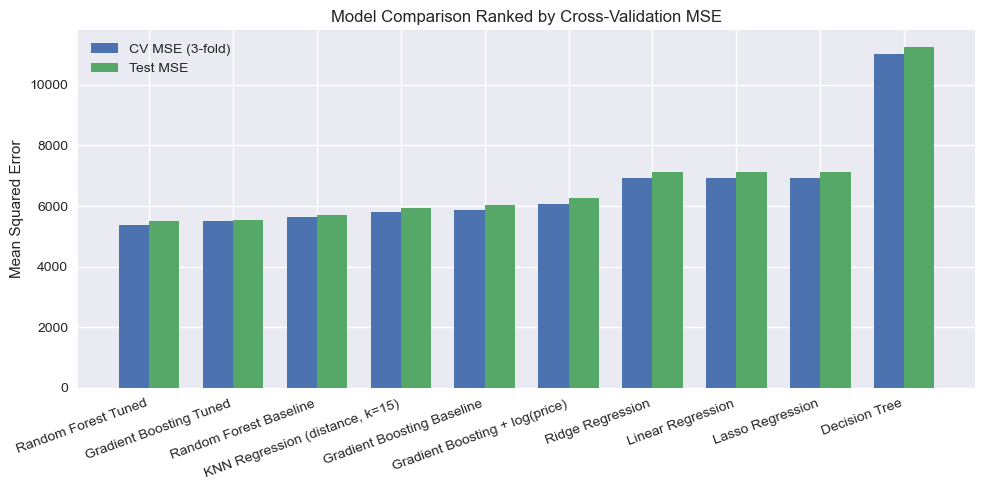

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(results_df))
ax.bar(x_pos - 0.18, results_df[cv_col], width=0.36, label=cv_col)
ax.bar(x_pos + 0.18, results_df['Test MSE'], width=0.36, label='Test MSE')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Model Comparison Ranked by Cross-Validation MSE')
ax.legend()
plt.tight_layout()
plt.show()



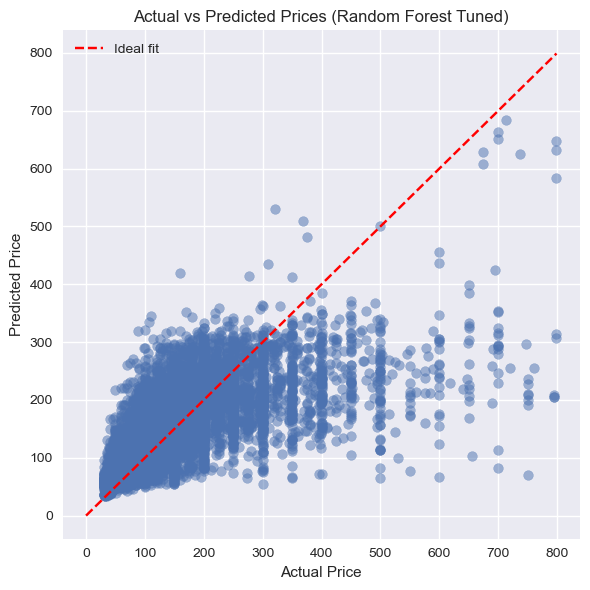

In [11]:
best_model = trained_models[best_model_name]
best_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.5)
max_val = max(y_test.max(), best_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Ideal fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Prices ({best_model_name})')
plt.legend()
plt.tight_layout()
plt.show()



## 10. Optimization and Final Modeling Strategy

The sections below extend the baseline workflow with targeted analysis to understand why the global model struggles, and to validate the final two-part prediction strategy.


## 2. Load and Clean Data


In [12]:
raw_df = pd.read_csv(DATA_PATH)
print(f'Original shape: {raw_df.shape}')

clean_df = raw_df.copy()
clean_df['reviews_per_month'] = clean_df['reviews_per_month'].fillna(0)
clean_df = clean_df.dropna(subset=['neighbourhood_group', 'room_type'])
clean_df = clean_df[clean_df['price'] > 0]
lower = clean_df['price'].quantile(0.01)
upper = clean_df['price'].quantile(0.99)
clean_df = clean_df[(clean_df['price'] >= lower) & (clean_df['price'] <= upper)].copy()

clean_df['last_review'] = pd.to_datetime(clean_df['last_review'])
latest_review_date = clean_df['last_review'].max()
clean_df['days_since_last_review'] = (
    latest_review_date - clean_df['last_review']
).dt.days
clean_df['days_since_last_review'] = clean_df['days_since_last_review'].fillna(-1)
clean_df['is_multi_listing_host'] = (
    clean_df['calculated_host_listings_count'] > 1
).astype(int)
clean_df['reviews_per_month_log'] = np.log1p(clean_df['reviews_per_month'])
clean_df['minimum_nights_log'] = np.log1p(clean_df['minimum_nights'])
clean_df['host_listings_log'] = np.log1p(clean_df['calculated_host_listings_count'])
clean_df['number_of_reviews_log'] = np.log1p(clean_df['number_of_reviews'])

print(f'Cleaned shape: {clean_df.shape}')
clean_df.head()


Original shape: (48895, 16)
Cleaned shape: (48017, 22)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,is_multi_listing_host,reviews_per_month_log,minimum_nights_log,host_listings_log,number_of_reviews_log
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,262.0,1,0.190620,0.693147,1.945910,2.302585
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,48.0,1,0.322083,0.693147,1.098612,3.828641
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,-1.0,0,0.000000,1.386294,0.693147,0.000000
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,3.0,0,1.729884,0.693147,0.693147,5.602119
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,231.0,0,0.095310,2.397895,0.693147,2.302585


## 3. Define Feature Sets

Start with a few interpretable groups so it is easy to see whether extra columns actually help.


In [13]:
feature_sets = {
    'location_core': [
        'latitude',
        'longitude',
        'neighbourhood_group',
        'room_type',
    ],
    'location_plus_neighbourhood': [
        'latitude',
        'longitude',
        'neighbourhood_group',
        'neighbourhood',
        'room_type',
    ],
    'current_workflow': [
        'latitude',
        'longitude',
        'minimum_nights',
        'number_of_reviews',
        'reviews_per_month',
        'calculated_host_listings_count',
        'availability_365',
        'neighbourhood_group',
        'room_type',
    ],
    'workflow_plus_neighbourhood': [
        'latitude',
        'longitude',
        'minimum_nights',
        'number_of_reviews',
        'reviews_per_month',
        'calculated_host_listings_count',
        'availability_365',
        'neighbourhood_group',
        'neighbourhood',
        'room_type',
    ],
    'workflow_minus_reviews': [
        'latitude',
        'longitude',
        'minimum_nights',
        'calculated_host_listings_count',
        'availability_365',
        'neighbourhood_group',
        'neighbourhood',
        'room_type',
    ],
    'engineered_full': [
        'latitude',
        'longitude',
        'minimum_nights',
        'minimum_nights_log',
        'number_of_reviews',
        'number_of_reviews_log',
        'reviews_per_month',
        'reviews_per_month_log',
        'calculated_host_listings_count',
        'host_listings_log',
        'availability_365',
        'days_since_last_review',
        'is_multi_listing_host',
        'neighbourhood_group',
        'neighbourhood',
        'room_type',
    ],
}

pd.DataFrame(
    {
        'Feature Set': feature_sets.keys(),
        'Feature Count': [len(cols) for cols in feature_sets.values()],
    }
)


,Feature Set,Feature Count
0,location_core,4
1,location_plus_neighbourhood,5
2,current_workflow,9
3,workflow_plus_neighbourhood,10
4,workflow_minus_reviews,8
5,engineered_full,16


## 4. Utilities for Preprocessing and Evaluation


In [14]:
def split_feature_types(feature_columns):
    numeric_columns = [
        col for col in feature_columns
        if pd.api.types.is_numeric_dtype(clean_df[col])
    ]
    categorical_columns = [
        col for col in feature_columns
        if col not in numeric_columns
    ]
    return numeric_columns, categorical_columns


def build_preprocessor(feature_columns):
    numeric_columns, categorical_columns = split_feature_types(feature_columns)

    transformers = []
    if numeric_columns:
        transformers.append(
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]),
                numeric_columns,
            )
        )
    if categorical_columns:
        transformers.append(
            (
                'cat',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(handle_unknown='ignore')),
                ]),
                categorical_columns,
            )
        )

    return ColumnTransformer(transformers=transformers)



def build_model_candidates(preprocessor):
    return {
        'Random Forest Baseline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        'Random Forest Stronger': Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(
                n_estimators=300,
                max_depth=16,
                min_samples_leaf=1,
                max_features='sqrt',
                random_state=RANDOM_STATE,
                n_jobs=1,
            )),
        ]),
        'Gradient Boosting Baseline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', GradientBoostingRegressor(random_state=RANDOM_STATE)),
        ]),
        'Gradient Boosting Tuned': Pipeline([
            ('preprocessor', preprocessor),
            ('model', GradientBoostingRegressor(
                n_estimators=500,
                learning_rate=0.1,
                max_depth=4,
                subsample=0.8,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
            )),
        ]),
        'Gradient Boosting Log Target': Pipeline([
            ('preprocessor', preprocessor),
            ('model', TransformedTargetRegressor(
                regressor=GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    subsample=0.8,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                ),
                func=np.log1p,
                inverse_func=np.expm1,
            )),
        ]),
    }


def evaluate_pipeline(name, pipeline, X_train, X_test, y_train, y_test):
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        n_jobs=1,
    )
    cv_mse = (-cv_scores).mean()

    pipeline.fit(X_train, y_train)
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    return {
        'Model': name,
        'Train MSE': mean_squared_error(y_train, train_pred),
        'Test MSE': mean_squared_error(y_test, test_pred),
        'Test RMSE': mean_squared_error(y_test, test_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test R2': r2_score(y_test, test_pred),
        f'CV MSE ({CV_FOLDS}-fold)': cv_mse,
        'fitted_model': pipeline,
        'test_predictions': test_pred,
    }
split_feature_types(['latitude', 'neighbourhood', 'room_type'])


(['latitude'], ['neighbourhood', 'room_type'])

## 8A. Final Random Forest Evaluation on Full Data

Lock in the current best random forest configuration and evaluate it on the full cleaned dataset with the original workflow feature set.


In [15]:
FINAL_FEATURE_SET_NAME = 'current_workflow'
FINAL_FEATURES = feature_sets[FINAL_FEATURE_SET_NAME]
FINAL_RF_PARAMS = {
    'n_estimators': 400,
    'max_depth': 16,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 5,
}

X_final = clean_df[FINAL_FEATURES]
y_final = clean_df['price']
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

final_preprocessor = build_preprocessor(FINAL_FEATURES)
final_rf_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **FINAL_RF_PARAMS,
    )),
])

final_cv_scores = cross_val_score(
    final_rf_pipeline,
    X_train_final,
    y_train_final,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    n_jobs=1,
)
final_cv_mse = (-final_cv_scores).mean()

final_rf_pipeline.fit(X_train_final, y_train_final)
final_train_pred = final_rf_pipeline.predict(X_train_final)
final_test_pred = final_rf_pipeline.predict(X_test_final)
final_residuals = y_test_final - final_test_pred

final_results = pd.Series({
    'Feature Set': FINAL_FEATURE_SET_NAME,
    'Train MSE': mean_squared_error(y_train_final, final_train_pred),
    'Test MSE': mean_squared_error(y_test_final, final_test_pred),
    'Test RMSE': mean_squared_error(y_test_final, final_test_pred) ** 0.5,
    'Test MAE': mean_absolute_error(y_test_final, final_test_pred),
    'Test R2': r2_score(y_test_final, final_test_pred),
    f'CV MSE ({CV_FOLDS}-fold)': final_cv_mse,
})

print('Final Random Forest parameters:')
print(FINAL_RF_PARAMS)
print()
final_results


Final Random Forest parameters:
{'n_estimators': 400, 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5}



Feature Set        current_workflow
Train MSE               3388.802262
Test MSE                5499.529699
Test RMSE                 74.158814
Test MAE                  44.842373
Test R2                    0.491705
CV MSE (3-fold)         5389.928008
dtype: object

## 8B. Grouped Error Analysis

Check where the model struggles most by price bucket, room type, and borough before deciding what to engineer next.


In [16]:
error_analysis_df = X_test_final.copy()
error_analysis_df['actual_price'] = y_test_final.values
error_analysis_df['predicted_price'] = final_test_pred
error_analysis_df['absolute_error'] = (
    error_analysis_df['actual_price'] - error_analysis_df['predicted_price']
).abs()
error_analysis_df['squared_error'] = (
    error_analysis_df['actual_price'] - error_analysis_df['predicted_price']
) ** 2

price_bins = [0, 100, 200, 300, 500, np.inf]
price_labels = ['<100', '100-200', '200-300', '300-500', '500+']
error_analysis_df['price_bucket'] = pd.cut(
    error_analysis_df['actual_price'],
    bins=price_bins,
    labels=price_labels,
    right=False,
)

def summarize_group_errors(df, group_col):
    return (
        df.groupby(group_col, observed=False)
        .agg(
            sample_size=('actual_price', 'size'),
            mean_actual_price=('actual_price', 'mean'),
            mean_predicted_price=('predicted_price', 'mean'),
            mae=('absolute_error', 'mean'),
            rmse=('squared_error', lambda s: np.sqrt(s.mean())),
        )
        .sort_values('mae', ascending=False)
    )

price_bucket_error_df = summarize_group_errors(error_analysis_df, 'price_bucket')
room_type_error_df = summarize_group_errors(error_analysis_df, 'room_type')
borough_error_df = summarize_group_errors(error_analysis_df, 'neighbourhood_group')

print('Error by price bucket')
display(price_bucket_error_df)
print('Error by room type')
display(room_type_error_df)
print('Error by borough')
display(borough_error_df)


Error by price bucket


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
price_bucket,,,,,
500+,143,610.076923,260.723030,349.353893,369.361148
300-500,581,365.784854,227.293505,140.257398,158.574612
200-300,1156,235.429931,207.532223,50.225870,63.236130
100-200,3398,140.031489,161.267086,39.511598,50.997756
<100,4326,65.756588,86.325851,24.710466,34.798519


Error by room type


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
room_type,,,,,
Entire home/apt,4999,188.414683,188.839209,62.476373,91.987261
Shared room,207,72.449275,77.427270,30.578515,51.956252
Private room,4398,85.340382,84.275741,25.469988,47.585822


Error by borough


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
neighbourhood_group,,,,,
Manhattan,4228,174.185194,173.008999,55.697531,86.207405
Staten Island,83,91.180723,90.237518,39.027764,78.462978
Brooklyn,3973,116.698465,118.056620,37.989560,64.093110
Bronx,229,88.646288,88.762206,31.623972,58.749778
Queens,1091,95.548121,93.805779,30.947084,58.815107


## 8C. Final Model Plots


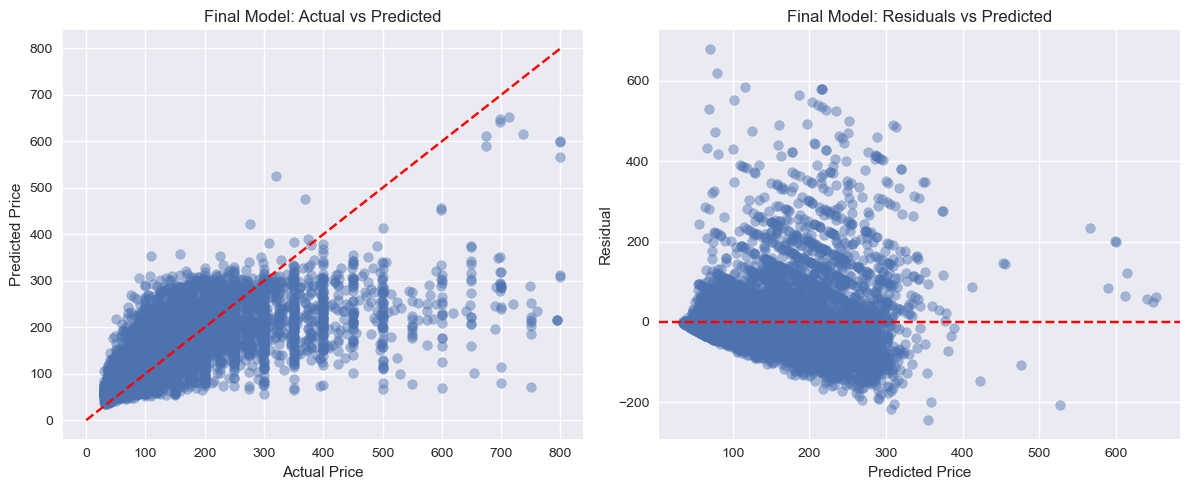

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_final, final_test_pred, alpha=0.45)
max_val = max(y_test_final.max(), final_test_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--')
axes[0].set_title('Final Model: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].scatter(final_test_pred, final_residuals, alpha=0.45)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Final Model: Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()


## 8E. High-Price and Entire-Home Error Analysis

Inspect the samples that drive most of the error so the next feature-engineering step can be more targeted.


In [18]:
high_price_threshold = 300
focused_error_df = error_analysis_df.copy()
focused_error_df['residual'] = focused_error_df['actual_price'] - focused_error_df['predicted_price']
focused_error_df['is_high_price'] = focused_error_df['actual_price'] >= high_price_threshold
focused_error_df['is_entire_home'] = focused_error_df['room_type'] == 'Entire home/apt'

# Bring back neighbourhood labels from the original cleaned frame for drill-down analysis.
focused_error_df = focused_error_df.join(clean_df[['neighbourhood']], how='left')

high_price_df = focused_error_df[focused_error_df['is_high_price']].copy()
entire_home_df = focused_error_df[focused_error_df['is_entire_home']].copy()
high_price_entire_home_df = focused_error_df[
    focused_error_df['is_high_price'] & focused_error_df['is_entire_home']
].copy()


def summarize_slice(name, df):
    if df.empty:
        return {
            'Slice': name,
            'sample_size': 0,
            'mean_actual_price': np.nan,
            'mean_predicted_price': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'mean_residual': np.nan,
        }

    return {
        'Slice': name,
        'sample_size': len(df),
        'mean_actual_price': df['actual_price'].mean(),
        'mean_predicted_price': df['predicted_price'].mean(),
        'mae': df['absolute_error'].mean(),
        'rmse': np.sqrt(df['squared_error'].mean()),
        'mean_residual': df['residual'].mean(),
    }


focused_slice_summary_df = pd.DataFrame([
    summarize_slice('High price (300+)', high_price_df),
    summarize_slice('Entire home/apt', entire_home_df),
    summarize_slice('High price + Entire home/apt', high_price_entire_home_df),
])

high_price_borough_df = summarize_group_errors(high_price_df, 'neighbourhood_group')
high_price_room_type_df = summarize_group_errors(high_price_df, 'room_type')
high_price_neighbourhood_df = (
    high_price_df.groupby('neighbourhood', observed=False)
    .agg(
        sample_size=('actual_price', 'size'),
        mean_actual_price=('actual_price', 'mean'),
        mean_predicted_price=('predicted_price', 'mean'),
        mae=('absolute_error', 'mean'),
        rmse=('squared_error', lambda s: np.sqrt(s.mean())),
    )
    .sort_values(['sample_size', 'mae'], ascending=[False, False])
    .head(15)
)

print('Focused slice summary')
display(focused_slice_summary_df)
print('High-price error by borough')
display(high_price_borough_df)
print('High-price error by room type')
display(high_price_room_type_df)
print('Top high-price neighbourhoods in the test split')
display(high_price_neighbourhood_df)



Focused slice summary


,Slice,sample_size,mean_actual_price,mean_predicted_price,mae,rmse,mean_residual
0,High price (300+),724,414.035912,233.896298,181.556844,217.084293,180.139614
1,Entire home/apt,4999,188.414683,188.839209,62.476373,91.987261,-0.424526
2,High price + Entire home/apt,626,413.351438,238.109537,176.389682,210.839851,175.241901


High-price error by borough


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
neighbourhood_group,,,,,
Staten Island,1,700.000000,115.285289,584.714711,584.714711
Bronx,5,404.800000,110.861285,293.938715,317.087213
Queens,27,429.296296,150.658079,278.638217,303.132073
Brooklyn,175,402.885714,193.773434,209.503769,238.107946
Manhattan,516,416.554264,253.281413,165.128595,201.119041


High-price error by room type


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
room_type,,,,,
Shared room,5,390.000000,149.861547,240.138453,240.585250
Private room,93,419.935484,210.054212,213.188407,254.035511
Entire home/apt,626,413.351438,238.109537,176.389682,210.839851


Top high-price neighbourhoods in the test split


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
neighbourhood,,,,,
Midtown,92,450.173913,310.366935,143.150060,187.481929
Hell's Kitchen,59,401.084746,247.660329,160.604869,185.724142
Chelsea,43,399.976744,241.872771,159.994220,199.168985
Williamsburg,42,403.095238,224.315367,180.411073,216.810258
East Village,40,408.200000,226.312282,181.887718,218.594890
Upper West Side,40,385.850000,233.458398,152.391602,177.640989
Upper East Side,29,429.172414,215.088798,214.083616,250.601649
Murray Hill,24,410.041667,250.329041,159.712626,195.925602
Bedford-Stuyvesant,22,420.954545,164.069734,256.884812,289.523872


## 8F. Segmented Modeling by Room Type

Train separate models by `room_type` to test whether a split between entire homes and room rentals reduces the average error.


In [19]:
SEGMENTED_FEATURES = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'neighbourhood_group',
]

segmented_results = []
segmented_predictions = []
segmented_models = {}
segment_cv_col = f'Segment CV MSE ({CV_FOLDS}-fold)'

for room_type_name in sorted(clean_df['room_type'].unique()):
    segment_df = clean_df[clean_df['room_type'] == room_type_name].copy()
    X_segment = segment_df[SEGMENTED_FEATURES]
    y_segment = segment_df['price']

    X_train_segment, X_test_segment, y_train_segment, y_test_segment = train_test_split(
        X_segment,
        y_segment,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    segment_preprocessor = build_preprocessor(SEGMENTED_FEATURES)
    segment_pipeline = Pipeline([
        ('preprocessor', segment_preprocessor),
        ('model', RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
            **FINAL_RF_PARAMS,
        )),
    ])

    segment_cv_scores = cross_val_score(
        segment_pipeline,
        X_train_segment,
        y_train_segment,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        n_jobs=1,
    )
    segment_cv_mse = (-segment_cv_scores).mean()

    segment_pipeline.fit(X_train_segment, y_train_segment)
    segment_pred = segment_pipeline.predict(X_test_segment)

    segmented_results.append({
        'room_type': room_type_name,
        'sample_size': len(segment_df),
        'Test MSE': mean_squared_error(y_test_segment, segment_pred),
        'Test RMSE': mean_squared_error(y_test_segment, segment_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test_segment, segment_pred),
        'Test R2': r2_score(y_test_segment, segment_pred),
        segment_cv_col: segment_cv_mse,
    })

    segmented_predictions.append(pd.DataFrame({
        'room_type': room_type_name,
        'actual_price': y_test_segment.values,
        'predicted_price': segment_pred,
    }))
    segmented_models[room_type_name] = segment_pipeline

segmented_results_df = pd.DataFrame(segmented_results).sort_values('Test MSE').reset_index(drop=True)
segmented_predictions_df = pd.concat(segmented_predictions, ignore_index=True)
segmented_overall_metrics = pd.Series({
    'Test MSE': mean_squared_error(segmented_predictions_df['actual_price'], segmented_predictions_df['predicted_price']),
    'Test RMSE': mean_squared_error(segmented_predictions_df['actual_price'], segmented_predictions_df['predicted_price']) ** 0.5,
    'Test MAE': mean_absolute_error(segmented_predictions_df['actual_price'], segmented_predictions_df['predicted_price']),
    'Test R2': r2_score(segmented_predictions_df['actual_price'], segmented_predictions_df['predicted_price']),
})

print('Per-room-type segmented results')
display(segmented_results_df)
print('Combined segmented-model performance across all room types')
display(segmented_overall_metrics)
print('Current global model baseline for comparison')
display(final_results[['Test MSE', 'Test RMSE', 'Test MAE', 'Test R2']])


Per-room-type segmented results


,room_type,sample_size,Test MSE,Test RMSE,Test MAE,Test R2,Segment CV MSE (3-fold)
0,Private room,22042,2160.992759,46.486479,25.202982,0.338626,2061.965739
1,Shared room,976,4907.350656,70.052485,31.652954,0.134036,2779.433164
2,Entire home/apt,24999,8135.105249,90.194818,61.759646,0.303344,8483.237843


Combined segmented-model performance across all room types


Test MSE     5326.932228
Test RMSE      72.985836
Test MAE       44.364618
Test R2         0.489540
dtype: float64

Current global model baseline for comparison


Test MSE     5499.529699
Test RMSE      74.158814
Test MAE       44.842373
Test R2         0.491705
dtype: object

## 8H. Typical Listings Model (price < 500)

Treat sub-$500 listings as the main prediction task and compare a segmented-by-room-type strategy against a single global model.


In [20]:
TYPICAL_PRICE_THRESHOLD = 500
typical_df = clean_df[clean_df['price'] < TYPICAL_PRICE_THRESHOLD].copy()

X_typical = typical_df[FINAL_FEATURES]
y_typical = typical_df['price']
X_train_typical, X_test_typical, y_train_typical, y_test_typical = train_test_split(
    X_typical,
    y_typical,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

typical_global_preprocessor = build_preprocessor(FINAL_FEATURES)
typical_global_pipeline = Pipeline([
    ('preprocessor', typical_global_preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **FINAL_RF_PARAMS,
    )),
])

typical_global_cv_scores = cross_val_score(
    typical_global_pipeline,
    X_train_typical,
    y_train_typical,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    n_jobs=1,
)
typical_global_cv_mse = (-typical_global_cv_scores).mean()
typical_global_pipeline.fit(X_train_typical, y_train_typical)
typical_global_pred = typical_global_pipeline.predict(X_test_typical)

typical_segmented_predictions = []
for room_type_name in sorted(typical_df['room_type'].unique()):
    room_df = typical_df[typical_df['room_type'] == room_type_name].copy()
    X_room = room_df[SEGMENTED_FEATURES]
    y_room = room_df['price']

    X_train_room, X_test_room, y_train_room, y_test_room = train_test_split(
        X_room,
        y_room,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    room_preprocessor = build_preprocessor(SEGMENTED_FEATURES)
    room_pipeline = Pipeline([
        ('preprocessor', room_preprocessor),
        ('model', RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
            **FINAL_RF_PARAMS,
        )),
    ])
    room_pipeline.fit(X_train_room, y_train_room)
    room_pred = room_pipeline.predict(X_test_room)

    typical_segmented_predictions.append(pd.DataFrame({
        'room_type': room_type_name,
        'actual_price': y_test_room.values,
        'predicted_price': room_pred,
    }))

typical_segmented_predictions_df = pd.concat(typical_segmented_predictions, ignore_index=True)

typical_results_df = pd.DataFrame([
    {
        'Model': 'Typical global model (<500)',
        'Sample Size': len(typical_df),
        'Test MSE': mean_squared_error(y_test_typical, typical_global_pred),
        'Test RMSE': mean_squared_error(y_test_typical, typical_global_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test_typical, typical_global_pred),
        'Test R2': r2_score(y_test_typical, typical_global_pred),
        f'CV MSE ({CV_FOLDS}-fold)': typical_global_cv_mse,
    },
    {
        'Model': 'Typical segmented model by room_type (<500)',
        'Sample Size': len(typical_df),
        'Test MSE': mean_squared_error(typical_segmented_predictions_df['actual_price'], typical_segmented_predictions_df['predicted_price']),
        'Test RMSE': mean_squared_error(typical_segmented_predictions_df['actual_price'], typical_segmented_predictions_df['predicted_price']) ** 0.5,
        'Test MAE': mean_absolute_error(typical_segmented_predictions_df['actual_price'], typical_segmented_predictions_df['predicted_price']),
        'Test R2': r2_score(typical_segmented_predictions_df['actual_price'], typical_segmented_predictions_df['predicted_price']),
        f'CV MSE ({CV_FOLDS}-fold)': np.nan,
    },
])

print(f'Typical-listings sample size (<{TYPICAL_PRICE_THRESHOLD}): {len(typical_df)}')
typical_results_df


Typical-listings sample size (<500): 47256


,Model,Sample Size,Test MSE,Test RMSE,Test MAE,Test R2,CV MSE (3-fold)
0,Typical global model (<500),47256,3308.983214,57.523762,38.425994,0.534302,3344.583726
1,Typical segmented model by room_type (<500),47256,3198.021036,56.551048,38.319598,0.555099,NaN


## 8I. High-Price Listings Analysis (price >= 500)

Describe the data scarcity and error profile for high-price listings before deciding whether to model them separately or treat them as an analysis-only slice.


In [21]:
high_price_only_df = clean_df[clean_df['price'] >= TYPICAL_PRICE_THRESHOLD].copy()
print(f'High-price sample size (>={TYPICAL_PRICE_THRESHOLD}): {len(high_price_only_df)}')

high_price_summary = pd.Series({
    'sample_size': len(high_price_only_df),
    'mean_price': high_price_only_df['price'].mean(),
    'median_price': high_price_only_df['price'].median(),
    'std_price': high_price_only_df['price'].std(),
    'min_price': high_price_only_df['price'].min(),
    'max_price': high_price_only_df['price'].max(),
})

high_price_room_distribution = high_price_only_df['room_type'].value_counts().to_frame('count')
high_price_borough_distribution = high_price_only_df['neighbourhood_group'].value_counts().to_frame('count')
high_price_neighbourhood_distribution = high_price_only_df['neighbourhood'].value_counts().head(15).to_frame('count')

display(high_price_summary)
print('High-price listings by room type')
display(high_price_room_distribution)
print('High-price listings by borough')
display(high_price_borough_distribution)
print('Top high-price neighbourhoods overall')
display(high_price_neighbourhood_distribution)


High-price sample size (>=500): 761


sample_size     761.000000
mean_price      606.629435
median_price    600.000000
std_price        91.878635
min_price       500.000000
max_price       799.000000
dtype: float64

High-price listings by room type


,count
room_type,
Entire home/apt,665
Private room,92
Shared room,4


High-price listings by borough


,count
neighbourhood_group,
Manhattan,557
Brooklyn,176
Queens,20
Bronx,6
Staten Island,2


Top high-price neighbourhoods overall


,count
neighbourhood,
Midtown,142
Williamsburg,56
Hell's Kitchen,50
Upper West Side,40
Chelsea,37
West Village,30
East Village,30
Upper East Side,30
SoHo,28


## 8J. Split-Task Comparison

Compare the current all-listings model against the typical-listings model so it is clear how much the high-price tail affects the overall error.


## 8L. High-Price Listings Model (price >= 500)

Train a dedicated random forest model for the high-price segment so the split-task strategy includes a real predictive model on both sides of the threshold.


In [22]:
HIGH_PRICE_FEATURES = FINAL_FEATURES
X_high = high_price_only_df[HIGH_PRICE_FEATURES]
y_high = high_price_only_df['price']

X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(
    X_high,
    y_high,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

high_preprocessor = build_preprocessor(HIGH_PRICE_FEATURES)
high_price_pipeline = Pipeline([
    ('preprocessor', high_preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **FINAL_RF_PARAMS,
    )),
])

high_cv_scores = cross_val_score(
    high_price_pipeline,
    X_train_high,
    y_train_high,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    n_jobs=1,
)
high_cv_mse = (-high_cv_scores).mean()

high_price_pipeline.fit(X_train_high, y_train_high)
high_test_pred = high_price_pipeline.predict(X_test_high)
high_residuals = y_test_high - high_test_pred

high_price_results = pd.Series({
    'Feature Set': 'current_workflow',
    'Sample Size': len(high_price_only_df),
    'Train MSE': mean_squared_error(y_train_high, high_price_pipeline.predict(X_train_high)),
    'Test MSE': mean_squared_error(y_test_high, high_test_pred),
    'Test RMSE': mean_squared_error(y_test_high, high_test_pred) ** 0.5,
    'Test MAE': mean_absolute_error(y_test_high, high_test_pred),
    'Test R2': r2_score(y_test_high, high_test_pred),
    f'CV MSE ({CV_FOLDS}-fold)': high_cv_mse,
})

print('High-price model parameters:')
print(FINAL_RF_PARAMS)
print()
high_price_results


High-price model parameters:
{'n_estimators': 400, 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5}



Feature Set        current_workflow
Sample Size                     761
Train MSE               3323.858523
Test MSE                6786.837427
Test RMSE                 82.382264
Test MAE                  66.416002
Test R2                    0.132731
CV MSE (3-fold)         7779.865856
dtype: object

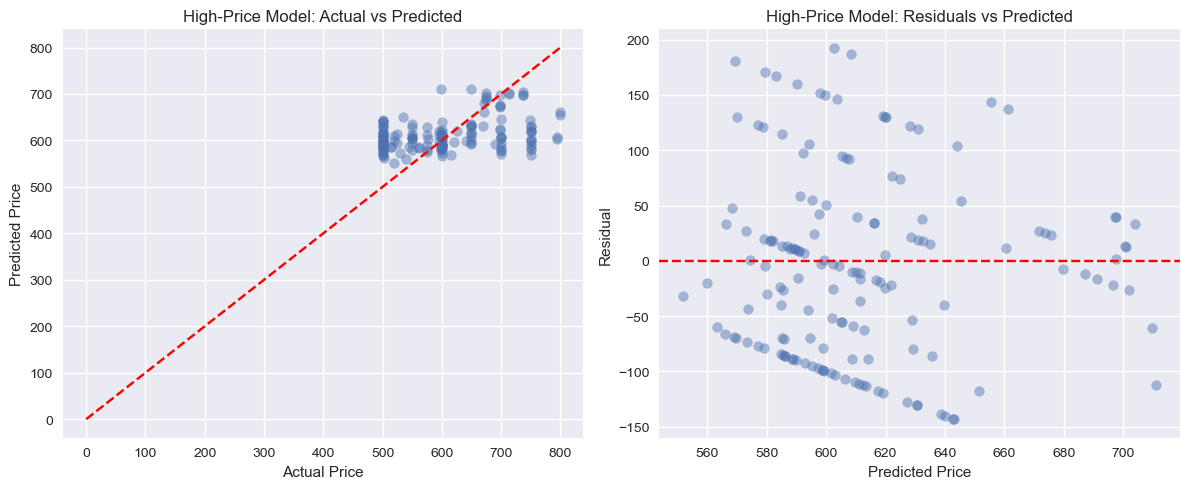

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_high, high_test_pred, alpha=0.45)
max_val = max(y_test_high.max(), high_test_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--')
axes[0].set_title('High-Price Model: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].scatter(high_test_pred, high_residuals, alpha=0.45)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('High-Price Model: Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()


## 8M. Two-Part Prediction Summary

Summarize the final two-part modeling strategy: a dedicated model for typical listings under `$500` and a separate model for high-price listings at or above `$500`.


In [24]:
two_part_summary_df = pd.DataFrame([
    {
        'Price Segment': '<500',
        'Model': 'Segmented random forest by room_type',
        'Sample Size': 47256,
        'Test MSE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test MSE'].iloc[0],
        'Test RMSE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test RMSE'].iloc[0],
        'Test MAE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test MAE'].iloc[0],
        'Test R2': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test R2'].iloc[0],
    },
    {
        'Price Segment': '>=500',
        'Model': 'Global random forest',
        'Sample Size': len(high_price_only_df),
        'Test MSE': high_price_results['Test MSE'],
        'Test RMSE': high_price_results['Test RMSE'],
        'Test MAE': high_price_results['Test MAE'],
        'Test R2': high_price_results['Test R2'],
    },
])

two_part_summary_df


,Price Segment,Model,Sample Size,Test MSE,Test RMSE,Test MAE,Test R2
0,<500,Segmented random forest by room_type,47256,3198.021036,56.551048,38.319598,0.555099
1,>=500,Global random forest,761,6786.837427,82.382264,66.416002,0.132731
